# 순환 신경망 — RNN, LSTM, Bi-LSTM 으로 수치형 시계열 다루기

## 목차

| 회차 | 파트 | 주제 | 핵심 |
|------|------|------|------|
| 1 | Part 1 | 시계열 데이터와 "순서"의 의미 | DNN의 한계, 슬라이딩 윈도우 |
| 2 | Part 2 | RNN의 구조 — 은닉 상태 | $h_t$, parameter sharing, 손계산 |
| 3 | Part 3 | RNN의 한계 — 장기 의존성 | BPTT, 기울기 소실 시뮬레이션 |
| 4 | Part 4 | LSTM의 등장 — 셀 상태 + 3 게이트 | $C_t$, forget·input·output 게이트 |
| 5 | Part 5 | PyTorch LSTM 시계열 예측 | sine 시계열 many-to-one 회귀 |
| 6 | Part 6 | 양방향 LSTM (Bi-LSTM) | 정방향+역방향, 사용 가능/불가 |
| 7 | Part 7 | 종합 실습 — 시계열 분류 | DNN vs 단방향 LSTM vs Bi-LSTM |

> 지난 시간(02 챕터)에서는 DNN으로 손글씨 이미지를 분류했고, "이미지의 위치 정보를 살리려면 CNN 이 필요하다"는 예고를 드렸습니다. CNN은 다음 챕터에서 본격적으로 다룹니다.
> 그 전에, **DNN으로는 거의 다룰 수 없는 또 하나의 데이터 유형**인 **시계열(sequence)** 을 먼저 만나보겠습니다. 이미지(공간 구조)와 시계열(시간 구조)은 "DNN의 일렬 펴기"가 정보를 잃게 하는 대표적인 두 사례이고, 각각의 해법이 CNN·RNN/LSTM 입니다.


In [1]:
# ============================================================
# 공통 설정 (이 셀을 가장 먼저 실행해주세요!)
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import platform
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
if platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
elif platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# 재현성을 위한 시드 고정
import torch
import torch.nn as nn
torch.manual_seed(42)
np.random.seed(42)

print(f"numpy: {np.__version__}")
print(f"torch: {torch.__version__}")
print(f"device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

numpy: 2.4.4
torch: 2.11.0
device: cpu


---

## Part 1: 시계열 데이터와 "순서"의 의미

### 시계열이란?

**시간 순서대로 관측된 데이터의 나열**입니다.

| 분야 | 시계열 예시 |
|------|------------|
| 기상 | 일별 평균기온, 시간별 미세먼지 농도 |
| 금융 | 주식 종가, 환율 |
| 의료 | 환자의 심전도(ECG), 혈당 측정값 |
| 산업 | 공장 센서 측정값, 서버 CPU 사용률 |

핵심 비유: 시계열은 **문장**과 같습니다. "나는 학교에 갔다"의 단어 순서를 섞으면 의미가 흐려지듯, 시계열도 **순서가 곧 정보**입니다.

<img src="images/03_rnn_lstm/time_series_intro.png" width="100%">

| 항목 | 일반 데이터 (Iris) | 시계열 데이터 |
|------|------------------|--------------|
| 각 행의 독립성 | 꽃 한 송이씩 독립 | 시점 t는 t-1과 강하게 연결 |
| 행 순서를 섞으면? | 영향 없음 | **정보 파괴** |
| 입력 길이 | 항상 고정 | 가변 (샘플마다 다를 수 있음) |
| 적합한 모델 | DNN, CNN | **RNN, LSTM, Transformer** |


### 그렇다면 DNN으로 시계열을 다루면?

DNN은 입력 벡터 $\mathbf{x} = [x_1, x_2, x_3]$ 에 가중치 $\mathbf{w} = [w_1, w_2, w_3]$ 를 곱해 더합니다.

$$z = w_1 x_1 + w_2 x_2 + w_3 x_3$$

3가지 한계가 있습니다.

1. **순서 정보를 구조적으로 활용하지 못합니다.** 입력을 $[x_3, x_1, x_2]$ 로 섞고 가중치도 같이 섞으면 결과는 동일합니다. DNN은 "어느 입력이 시간상 먼저였는지"를 모릅니다.
2. **입력 길이가 고정되어야 합니다.** 환자 A는 100일치, B는 365일치라면? DNN은 곤란합니다.
3. **동일한 패턴이 다른 위치에 있으면 다르게 봅니다.** "최근 3일 급상승" 패턴이 윈도우 1~3번에 있을 때와 5~7번에 있을 때를 DNN은 완전히 다른 입력으로 처리합니다.

> 이 한계를 해결하려면 **순서대로 데이터를 보면서 정보를 누적해 가는 모델**이 필요합니다.
> 그것이 다음 Part의 주인공인 **RNN** 입니다.

### 슬라이딩 윈도우 — 시계열을 (X, y) 쌍으로

긴 시계열 한 줄로는 모델을 학습할 수 없습니다. **(과거 W 스텝, 다음 1 스텝)** 쌍을 여러 개 만들어야 합니다. 이 구조를 **many-to-one** 이라 부릅니다.

<img src="images/03_rnn_lstm/sliding_window.png" width="80%">

> ⚠️ **시계열 분할의 주의점**: 학습/검증 분할 시 **시간 순서를 지켜야** 합니다.
> 무작위 셔플 후 분할하면 검증 데이터가 학습 시점보다 과거일 수 있고, 이는 **미래 정보 누수** 입니다.
> 올바른 방법: 시계열의 앞 80%를 학습, 뒤 20%를 검증으로 사용합니다.


In [2]:
# [시나리오] 슬라이딩 윈도우로 시계열을 (X, y) 쌍으로 변환하는 함수를 정의합니다.
# 입력: 길이 6짜리 작은 시계열, 윈도우 크기 W=3
# 출력: 학습용 (X, y) 쌍 3개

def make_windows(series, window_size):
    """시계열을 (입력 윈도우, 다음 값) 쌍으로 변환합니다 (many-to-one).

    수식: 길이 N, 윈도우 W → 학습 쌍 (N - W) 개
        쌍 i: X_i = [series[i], series[i+1], ..., series[i+W-1]]
              y_i = series[i+W]
    """
    X, y = [], []
    for i in range(len(series) - window_size):
        X.append(series[i : i + window_size])
        y.append(series[i + window_size])
    return np.array(X), np.array(y)


ex = np.array([10, 20, 30, 40, 50, 60])
X_ex, y_ex = make_windows(ex, window_size=3)

print(f"원본 시계열: {ex}")
print(f"입력 X (shape={X_ex.shape}):")
for i, (xi, yi) in enumerate(zip(X_ex, y_ex)):
    print(f"  쌍 {i}: 과거 = {xi.tolist()}  →  다음 = {yi}")

print()
print("해석: 길이 6 시계열에서 (과거 3, 다음 1) 쌍 3개가 만들어졌습니다.")
print("      이 쌍들이 RNN/LSTM 의 학습 데이터가 됩니다.")


# 3, 3, 1
# B, W, D
# 100, 3, 1 <-- 100쌍, 1Epoch 훈련데이터 전체
# 10, 3, 1 <--- 1 Step 훈련시 들어가는 데이터 양


원본 시계열: [10 20 30 40 50 60]
입력 X (shape=(3, 3)):
  쌍 0: 과거 = [10, 20, 30]  →  다음 = 40
  쌍 1: 과거 = [20, 30, 40]  →  다음 = 50
  쌍 2: 과거 = [30, 40, 50]  →  다음 = 60

해석: 길이 6 시계열에서 (과거 3, 다음 1) 쌍 3개가 만들어졌습니다.
      이 쌍들이 RNN/LSTM 의 학습 데이터가 됩니다.


---

## Part 2: RNN의 구조 — 은닉 상태와 시간 펼치기

### 핵심 아이디어

> "시계열을 순서대로 보면서, 지금까지 본 것을 한 벡터에 압축한다."

비유: 책을 한 페이지씩 읽으며 줄거리를 머릿속에 정리하는 것과 같습니다.
- 새 페이지(=새 입력 $x_t$)를 읽을 때
- 지금까지의 줄거리(=이전 은닉 상태 $h_{t-1}$)를 함께 떠올리고
- 새 줄거리(=새 은닉 상태 $h_t$)로 갱신합니다.

### 수식

시점 $t$ 에서:

$$h_t = \tanh(W_{xh} \cdot x_t + W_{hh} \cdot h_{t-1} + b_h)$$
$$y_t = W_{hy} \cdot h_t + b_y$$

| 기호 | 의미 |
|------|------|
| $x_t$ | 시점 $t$의 입력 |
| $h_{t-1}$ | 이전 시점까지의 정보 요약 |
| $h_t$ | 시점 $t$까지의 정보 요약 |
| $W_{xh}, W_{hh}, b_h$ | 학습되는 가중치 (모든 시점에서 **공유**) |

> 핵심: **모든 시점이 같은 가중치를 사용**합니다 (parameter sharing).
> 시점 1과 시점 100이 동일한 $W$ 를 씁니다 → 가변 길이 시퀀스도 처리 가능합니다.

<img src="images/03_rnn_lstm/rnn_unroll.png" width="100%">

### 입출력 구조

본 교안은 **many-to-one** (시퀀스 입력 → 단일 출력) 만 다룹니다. 다른 구조(many-to-many, one-to-many)는 다음 챕터의 Seq2Seq 에서 만나게 됩니다.


In [3]:
# [시나리오] 작은 RNN을 시점 3까지 직접 계산해 봅니다.
# 입력: x = [0.5, 0.8, -0.3] (3 timestep, 1 feature)
# 가중치는 임의로 고정하고, h_0 = 0 에서 시작합니다.

W_xh, W_hh, b_h = 0.6, 0.5, 0.1
x = [0.5, 0.8, -0.3]

print("step | x_t    | h_{t-1}   | tanh 안 인자 | h_t")
print("-" * 60)
h_prev = 0.0
for step, xt in enumerate(x, start=1):
    z = W_xh * xt + W_hh * h_prev + b_h
    h_t = float(np.tanh(z))
    print(f"  {step}  | {xt:+.2f} | {h_prev:+.4f}   | {z:+.4f}      | {h_t:+.4f}")
    h_prev = h_t

print()
print("관찰 포인트:")
print(f"  - 매 시점 h_t = tanh(W_xh * x_t + W_hh * h_(t-1) + b) 으로 갱신됩니다.")
print(f"  - 최종 h_3 = {h_prev:.4f} 는 입력 시퀀스 전체를 압축한 벡터입니다.")
print(f"  - many-to-one 구조라면 이 h_3 로 다음 값을 예측하거나 분류합니다.")


step | x_t    | h_{t-1}   | tanh 안 인자 | h_t
------------------------------------------------------------
  1  | +0.50 | +0.0000   | +0.4000      | +0.3799
  2  | +0.80 | +0.3799   | +0.7700      | +0.6469
  3  | -0.30 | +0.6469   | +0.2435      | +0.2388

관찰 포인트:
  - 매 시점 h_t = tanh(W_xh * x_t + W_hh * h_(t-1) + b) 으로 갱신됩니다.
  - 최종 h_3 = 0.2388 는 입력 시퀀스 전체를 압축한 벡터입니다.
  - many-to-one 구조라면 이 h_3 로 다음 값을 예측하거나 분류합니다.


In [4]:
# [시나리오] PyTorch nn.RNN 의 입출력 shape 을 확인합니다.
# 입력: 임의 텐서 (batch=4, time=10, feature=1)
# 출력: out (모든 시점 hidden), h_T (마지막 시점 hidden)

rnn = nn.RNN(input_size=1, hidden_size=8, batch_first=True)
x_seq = torch.randn(4, 10, 1)
out, h_T = rnn(x_seq)

print(f"x_seq.shape: {tuple(x_seq.shape)}  # (batch=4, time=10, feature=1)")
print(f"out.shape:   {tuple(out.shape)}    # (batch=4, time=10, hidden=8) — 모든 시점 hidden")

# out[:, -1, :] 
# h_T
print(f"h_T.shape:   {tuple(h_T.shape)}    # (num_layers=1, batch=4, hidden=8) — 마지막 hidden")
print()
print("관찰 포인트:")
print("  - out 은 시점별 h_t 모두를 담고 있습니다.")
print("  - many-to-one 이라면 out[:, -1, :] 즉 마지막 hidden 만 사용합니다.")


x_seq.shape: (4, 10, 1)  # (batch=4, time=10, feature=1)
out.shape:   (4, 10, 8)    # (batch=4, time=10, hidden=8) — 모든 시점 hidden
h_T.shape:   (1, 4, 8)    # (num_layers=1, batch=4, hidden=8) — 마지막 hidden

관찰 포인트:
  - out 은 시점별 h_t 모두를 담고 있습니다.
  - many-to-one 이라면 out[:, -1, :] 즉 마지막 hidden 만 사용합니다.


---

## Part 3: RNN의 한계 — 장기 의존성과 기울기 소실

### 장기 의존성이란?

> "어제 도서관에서 만난 그 친구와, 우리는 1시간 동안 즐겁게 ___."

빈칸을 "**대화했다**" 로 채우려면 멀리 떨어진 단어 "친구"의 정보가 필요합니다. RNN은 이런 **멀리 떨어진 정보의 의존성** 을 잘 잡지 못합니다.

시계열 예시: 환자의 ECG 1000스텝 중 도입부(시점 50)에 보였던 작은 이상이 후반부 진단에 결정적이라면, 단순 RNN 은 시점 50의 정보를 시점 1000까지 전달하기 어렵습니다.

### 왜 그럴까? — BPTT의 곱셈 구조

손실 $L$ 의 $h_0$ 에 대한 기울기는 시간 축으로 곱해집니다.

$$\frac{\partial L}{\partial h_0} = \frac{\partial L}{\partial h_T} \cdot \prod_{t=1}^{T} \frac{\partial h_t}{\partial h_{t-1}}$$

각 항은:

$$\frac{\partial h_t}{\partial h_{t-1}} = \text{diag}(1 - h_t \odot h_t) \cdot W_{hh}$$

(diag는 대각행렬 — $h_t$ 의 원소별 제곱을 대각에 놓습니다. 그 뒤에 행렬곱 $W_{hh}$ 가 곱해집니다.)

핵심 문제:
- $\tanh$ 미분의 원소 $1 - (h_t)_i^2 \in (0, 1]$ — 보통 0.5 이하
- 단순 추정: $T=50$, 평균 미분 $\approx 0.5$ 이면 $(0.5)^{50} \approx 8 \times 10^{-16}$ — **거의 0**
- 실제 학습 상황은 더 가혹 (평균 미분 ~0.3) → 다음 시뮬레이션에서 더 작은 값 확인

**기울기 소실(vanishing gradient)**: 깊은 시점의 정보가 학습 신호로 전달되지 않습니다.


In [5]:
# [시나리오] T=50 RNN의 기울기 누적 곱을 시점별로 계산합니다.
# 입력: 임의 활성화의 tanh 미분 ~ U(0, 0.6) (학습 중 평균적인 값)
# 출력: 시점이 깊을수록 기울기 곱이 0으로 수렴함을 확인

np.random.seed(0)
T = 50
tanh_deriv = np.random.uniform(0.0, 0.6, T)   # (1 - h_t^2), 평균 ~0.3
W_hh = 0.8

prods = []
prod = 1.0
for step in range(T):
    prod *= tanh_deriv[step] * W_hh
    prods.append(abs(prod))

print(f"시점  1  기울기: {prods[0]:.4e}")
print(f"시점 10  기울기: {prods[9]:.4e}")
print(f"시점 25  기울기: {prods[24]:.4e}")
print(f"시점 50  기울기: {prods[49]:.4e}")
print()
print("관찰 포인트:")
print("  - 본문 단순 추정 (0.5)^50 ≈ 8e-16 보다도 훨씬 작은 7.8e-36 이 나왔습니다.")
print("  - 그 이유: 실제 학습에서 tanh 미분 평균이 0.5 보다 작은 ~0.3 이고,")
print("           W_hh 도 1보다 작은 0.8 을 곱하기 때문입니다.")
print("  - 결론: 두 추정 모두 '거의 0' 이라는 결론은 같으며, 단순 RNN 의 기울기는")
print("           50 스텝만에 사실상 사라집니다.")

시점  1  기울기: 2.6343e-01
시점 10  기울기: 3.3024e-06
시점 25  기울기: 2.8268e-17
시점 50  기울기: 7.8324e-36

관찰 포인트:
  - 본문 단순 추정 (0.5)^50 ≈ 8e-16 보다도 훨씬 작은 7.8e-36 이 나왔습니다.
  - 그 이유: 실제 학습에서 tanh 미분 평균이 0.5 보다 작은 ~0.3 이고,
           W_hh 도 1보다 작은 0.8 을 곱하기 때문입니다.
  - 결론: 두 추정 모두 '거의 0' 이라는 결론은 같으며, 단순 RNN 의 기울기는
           50 스텝만에 사실상 사라집니다.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

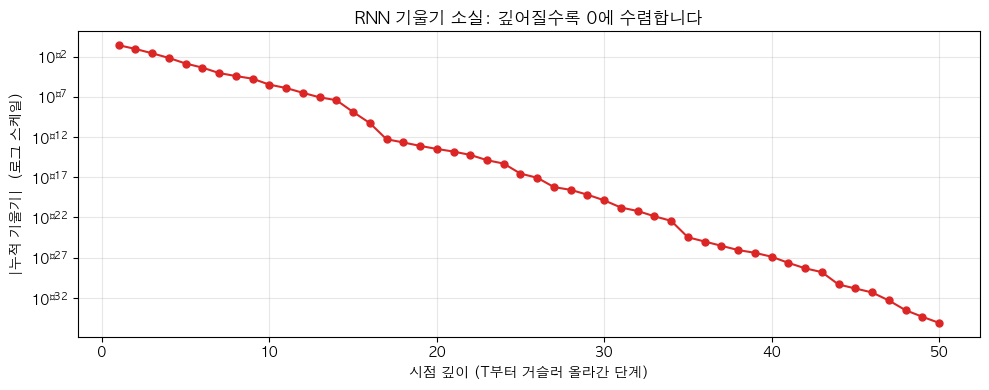

관찰 포인트:
  - y축이 로그 스케일이지만 곡선이 가파르게 떨어집니다.
  - 단순 RNN은 50 스텝 이전 정보로부터 학습하기가 매우 어렵습니다.
  - 이 문제를 해결하기 위해 다음 Part 의 LSTM 이 등장합니다.


In [6]:
# [시나리오] 위 시뮬레이션 결과를 로그 스케일로 시각화합니다.

plt.figure(figsize=(10, 4))
plt.plot(range(1, T + 1), prods, 'o-', color='#DC2626', markersize=5)
plt.yscale('log')
plt.xlabel("시점 깊이 (T부터 거슬러 올라간 단계)")
plt.ylabel("|누적 기울기|  (로그 스케일)")
plt.title("RNN 기울기 소실: 깊어질수록 0에 수렴합니다")
plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("관찰 포인트:")
print("  - y축이 로그 스케일이지만 곡선이 가파르게 떨어집니다.")
print("  - 단순 RNN은 50 스텝 이전 정보로부터 학습하기가 매우 어렵습니다.")
print("  - 이 문제를 해결하기 위해 다음 Part 의 LSTM 이 등장합니다.")


### 해결 방안

| 시도 | 핵심 아이디어 | 효과 |
|------|-------------|------|
| Gradient Clipping | 기울기 크기 상한 설정 | 폭발만 막음. 소실엔 무력 |
| **LSTM** (1997) | 셀 상태 + 게이트로 정보 흐름 제어 | **근본 해결** → 다음 Part |

> GRU·Transformer 등 다른 해법도 있지만, 본 교안에서는 **가장 영향력 있고 표준적인 LSTM** 에 집중합니다. 이후 발전은 마지막 챕터의 "다음 시간 예고" 에서 만나게 됩니다.


---

## Part 4: LSTM의 등장 — 셀 상태와 3개 게이트

### 핵심 아이디어

> "중요한 정보는 그대로 흘려보내고, 새 정보는 선택적으로 더하고, 필요 없는 정보는 잊자."

비유: 회의 중인 비서가 메모장에 핵심만 적어두는 것과 같습니다.
- **망각**: 오래되거나 중요하지 않은 메모를 지웁니다
- **입력**: 새 안건을 메모장에 추가합니다
- **출력**: 다음 발표자에게 메모장의 일부만 전달합니다

이 "메모장"이 바로 **셀 상태(cell state) $C_t$** 입니다. 은닉 상태 $h_t$ 와 별도로 흐르는 두 번째 정보 통로입니다.

<img src="images/03_rnn_lstm/rnn_vs_lstm.png" width="100%">

### LSTM 수식 (시점 $t$)

**3개의 게이트** (각각 0~1 사이의 값을 출력하는 시그모이드):

$$f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f) \quad \text{망각 게이트(forget)}$$
$$i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i) \quad \text{입력 게이트(input)}$$
$$o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o) \quad \text{출력 게이트(output)}$$

**후보 셀 상태**:
$$\tilde{C}_t = \tanh(W_C \cdot [h_{t-1}, x_t] + b_C)$$

**상태 업데이트 (핵심!)**:
$$C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t$$
$$h_t = o_t \odot \tanh(C_t)$$

여기서 $\odot$ 는 원소별 곱입니다.

> 📌 **PyTorch 구현 표기 차이**: 위 수식은 입력 $[h_{t-1}, x_t]$ 를 concat 해서 하나의 가중치 $W_f$ 를 곱하는 형태입니다.
> 💡 **왜 게이트는 σ, 후보는 tanh 인가요?**
> $\sigma$ 출력 ∈ [0, 1] = "정보를 얼마나 통과시킬 비율" (게이트 본연의 의미)
> $\tanh$ 출력 ∈ [-1, 1] = "새로 더할 정보 후보" (양/음 모두 가능해야 함)

<img src="images/03_rnn_lstm/lstm_gates.png" width="100%">

### 게이트의 역할

| 게이트 | 의미 | 비유 |
|--------|------|------|
| **망각** $f_t$ | "이전 셀 상태에서 무엇을 지울까?" | 오래된 메모 지우기 |
| **입력** $i_t$ | "새 후보 정보를 얼마나 받아들일까?" | 새 안건 메모 추가 |
| **출력** $o_t$ | "셀 상태의 어떤 부분을 hidden 으로 내보낼까?" | 메모장에서 일부만 발표 |

### 왜 기울기 소실이 해결될까?

핵심: **셀 상태의 업데이트가 덧셈** 이라서 그렇습니다.

$$C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t$$

지배적 미분 경로:

$$\frac{\partial C_t}{\partial C_{t-1}} \approx \text{diag}(f_t)$$

활성화 함수의 미분이 직접 곱해지지 않습니다. 모델이 학습으로 **장기 의존성에 필요한 신호에 대해 $f_t \approx 1$** 이 되도록 익히면, 깊은 시점까지 기울기가 거의 그대로 살아남습니다 — 이를 **정보 고속도로(information highway)** 라고 부릅니다.


In [7]:
# [시나리오] PyTorch nn.LSTM 의 입출력 shape 을 확인합니다.
# 입력: (batch=4, time=10, feature=1)
# 출력: out (모든 시점 hidden), (h_T, c_T) (마지막 hidden, 마지막 cell)

lstm = nn.LSTM(input_size=1, hidden_size=8, batch_first=True)
x_seq = torch.randn(4, 10, 1)
out, (h_T, c_T) = lstm(x_seq)

print(f"x_seq.shape: {tuple(x_seq.shape)}  # (batch, time, feature)")
print(f"out.shape:   {tuple(out.shape)}    # (batch, time, hidden) — 모든 시점 hidden") 
print(f"h_T.shape:   {tuple(h_T.shape)}    # (num_layers, batch, hidden) — 마지막 hidden")
print(f"c_T.shape:   {tuple(c_T.shape)}    # (num_layers, batch, hidden) — 마지막 cell")
print()
print("관찰 포인트:")
print("  - RNN과 달리 cell state c_T 가 추가로 반환됩니다.")
print("  - many-to-one 분류·예측은 보통 out[:, -1, :] (마지막 hidden) 만 사용합니다.")
print("  - h_0, c_0 를 따로 안 주면 PyTorch 가 자동으로 0 텐서로 초기화합니다.")


x_seq.shape: (4, 10, 1)  # (batch, time, feature)
out.shape:   (4, 10, 8)    # (batch, time, hidden) — 모든 시점 hidden
h_T.shape:   (1, 4, 8)    # (num_layers, batch, hidden) — 마지막 hidden
c_T.shape:   (1, 4, 8)    # (num_layers, batch, hidden) — 마지막 cell

관찰 포인트:
  - RNN과 달리 cell state c_T 가 추가로 반환됩니다.
  - many-to-one 분류·예측은 보통 out[:, -1, :] (마지막 hidden) 만 사용합니다.
  - h_0, c_0 를 따로 안 주면 PyTorch 가 자동으로 0 텐서로 초기화합니다.


---

## Part 5: PyTorch LSTM 으로 시계열 예측

이제 LSTM을 직접 학습시켜 합성 사인파 시계열을 예측해 봅니다.

### 데이터: 사인파 + 노이즈

$$y_t = \sin\left(\frac{2\pi t}{50}\right) + \varepsilon_t, \quad \varepsilon_t \sim \mathcal{N}(0, 0.1^2), \quad t = 0, 1, \dots, 599$$


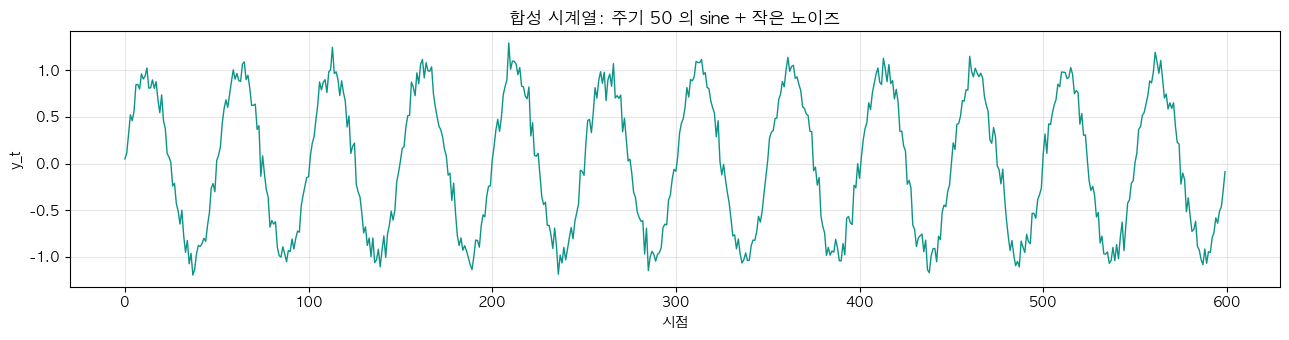

길이: 600, 평균: -0.001, 표준편차: 0.721


In [8]:
# [시나리오] 600 스텝짜리 합성 시계열 (sine + 작은 노이즈)을 만듭니다.
# 입력: 시점 0~599
# 출력: 길이 600 시계열

T_total = 600
rng = np.random.RandomState(42)
t = np.arange(T_total)
series = np.sin(2 * np.pi * t / 50) + rng.normal(0, 0.1, T_total)

plt.figure(figsize=(13, 3.5))
plt.plot(t, series, color='#0D9488', linewidth=1.0)
plt.title("합성 시계열: 주기 50 의 sine + 작은 노이즈")
plt.xlabel("시점"); plt.ylabel("y_t")
plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"길이: {T_total}, 평균: {series.mean():.3f}, 표준편차: {series.std():.3f}")


In [9]:
# [시나리오] 시간 순으로 train/val 분할 + 정규화 + 슬라이딩 윈도우.
# - 윈도우 W=20: 과거 20 스텝 보고 다음 1 스텝 예측 (many-to-one)
# - 분할: 앞 480 학습, 뒤 120 검증 (시간 순! 셔플 금지)
# - 정규화: 학습셋 통계만 사용 → 미래 정보 누수 방지

W = 20
split = 480

train_series = series[:split]
val_series = series[split:]

# z정규화
mu, sigma = train_series.mean(), train_series.std()
train_norm = (train_series - mu) / sigma
val_norm = (val_series - mu) / sigma

X_tr, y_tr = make_windows(train_norm, W) #X_tr.shape: (460, 20), y_tr.shape: (460,)
X_val, y_val = make_windows(val_norm, W) # X_val.shape: (100, 20), y_val.shape: (100,)

print(f"X_tr.shape: {X_tr.shape}, y_tr.shape: {y_tr.shape}")
print(f"X_val.shape: {X_val.shape}, y_val.shape: {y_val.shape}")
print()
print("관찰 포인트:")
print(f"  - 학습 윈도우 수 = 480 - W = {480 - W}")
print(f"  - 검증 윈도우 수 = 120 - W = {120 - W}")
print(f"  - 정규화는 학습셋 통계만 사용 → 미래 누수 없음")


X_tr.shape: (460, 20), y_tr.shape: (460,)
X_val.shape: (100, 20), y_val.shape: (100,)

관찰 포인트:
  - 학습 윈도우 수 = 480 - W = 460
  - 검증 윈도우 수 = 120 - W = 100
  - 정규화는 학습셋 통계만 사용 → 미래 누수 없음


### 모델 정의

`nn.LSTM` 의 주요 옵션을 정리합니다.

| 옵션 | 의미 | 본 교안 사용값 |
|------|------|---------------|
| `input_size` | 한 시점의 feature 차원 | 1 (단일 변수) |
| `hidden_size` | 은닉 상태 차원 | 32 |
| `num_layers` | LSTM 층 수 (≥2 면 Stacked LSTM) | 1 |
| `batch_first` | True 면 입력 shape `(B, T, F)`, False 면 `(T, B, F)` | True |
| `bidirectional` | True 면 Bi-LSTM | False |
| `dropout` | `num_layers ≥ 2` 일 때만 동작, 층 사이 dropout | 0.0 |

> 💡 `h_0, c_0` 를 별도 인자로 주지 않으면 PyTorch 가 자동으로 0 텐서로 초기화합니다.

> 💡 hidden_size 는 보통 16~128 사이에서 데이터 크기에 비례해 선택합니다. 본 교안은 빠른 학습을 위해 32 를 사용하지만, 실무에서는 64~256 이 흔합니다.


In [10]:
# [시나리오] LSTM 회귀 모델을 정의하고 학습 데이터의 텐서 shape 을 확인합니다.

X_tr_t  = torch.tensor(X_tr,  dtype=torch.float32).unsqueeze(-1)
y_tr_t  = torch.tensor(y_tr,  dtype=torch.float32).unsqueeze(-1)
X_val_t = torch.tensor(X_val, dtype=torch.float32).unsqueeze(-1)
y_val_t = torch.tensor(y_val, dtype=torch.float32).unsqueeze(-1)

print(f"X_tr_t.shape: {tuple(X_tr_t.shape)}  # (batch, time=20, feature=1)") #X_tr_t.shape: (460, 20, 1)  # (batch, time=20, feature=1)
print(f"y_tr_t.shape: {tuple(y_tr_t.shape)}  # (batch, 1)") # y_tr_t.shape: (460, 1)  # (batch, 1)
print()


class LSTMRegressor(nn.Module):
    def __init__(self, hidden_size=32):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=hidden_size,
                            num_layers=1, batch_first=True)
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, (h_T, c_T) = self.lstm(x)         # out: (batch, time, hidden)
        last_hidden = out[:, -1, :]            # many-to-one: 마지막 시점만
        return self.head(last_hidden)          # (batch, 1)


model = LSTMRegressor(hidden_size=32)
print(model)
print(f"파라미터 개수: {sum(p.numel() for p in model.parameters()):,}")


X_tr_t.shape: (460, 20, 1)  # (batch, time=20, feature=1)
y_tr_t.shape: (460, 1)  # (batch, 1)

LSTMRegressor(
  (lstm): LSTM(1, 32, batch_first=True)
  (head): Linear(in_features=32, out_features=1, bias=True)
)
파라미터 개수: 4,513


In [11]:
# [시나리오] LSTM 회귀 모델을 학습합니다.
# - AdamW(lr=1e-3, weight_decay=1e-4) — 02 챕터에서 권장한 옵티마이저
# - MSELoss, batch=32, 50 epoch

from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(42)
np.random.seed(42)

train_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=32, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=32, shuffle=False)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4) #최종 Loss = 기존 로스 + 학습 웨이트 페널티!
loss_fn = nn.MSELoss()
# 위 설정은 02 챕터 종합실습과 동일한 옵티마이저 설정입니다.

EPOCHS = 50
train_losses, val_losses = [], []
for ep in range(EPOCHS):
    model.train()
    s = 0.0
    for Xb, yb in train_loader:
        optimizer.zero_grad()
        loss = loss_fn(model(Xb), yb)
        loss.backward()
        optimizer.step()
        s += loss.item() * Xb.size(0)
    train_losses.append(s / len(train_loader.dataset))

    model.eval()
    s = 0.0
    with torch.no_grad():
        for Xb, yb in val_loader:
            s += loss_fn(model(Xb), yb).item() * Xb.size(0)
    val_losses.append(s / len(val_loader.dataset))

    if (ep + 1) % 10 == 0:
        print(f"epoch {ep+1:02d} | train MSE {train_losses[-1]:.4f} | val MSE {val_losses[-1]:.4f}")

print()
print(f"최종 val MSE: {val_losses[-1]:.4f}")


epoch 10 | train MSE 0.0261 | val MSE 0.0231
epoch 20 | train MSE 0.0238 | val MSE 0.0214
epoch 30 | train MSE 0.0230 | val MSE 0.0197
epoch 40 | train MSE 0.0221 | val MSE 0.0189
epoch 50 | train MSE 0.0213 | val MSE 0.0188

최종 val MSE: 0.0188


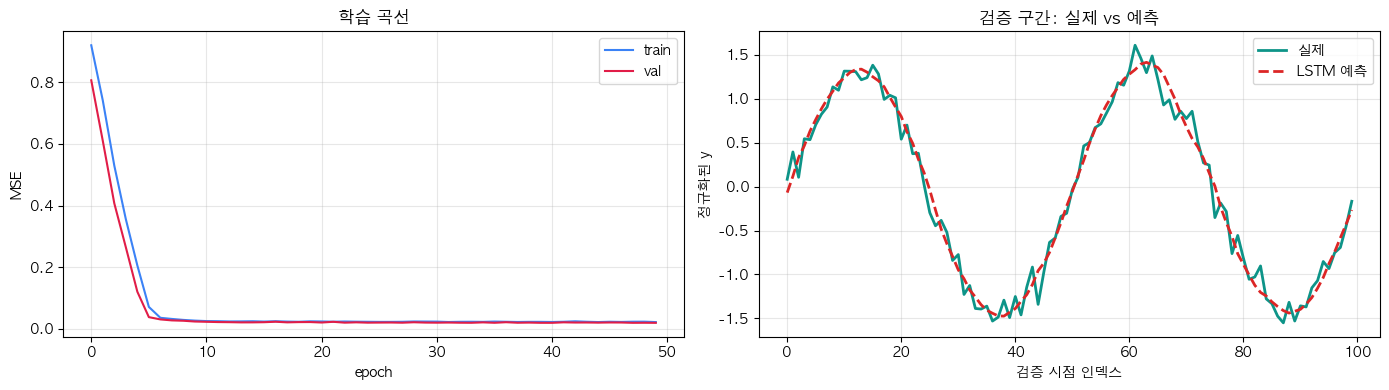

검증 RMSE (정규화 단위): 0.1373
노이즈 floor (정규화):    0.1391

관찰 포인트:
  - 학습/검증 손실이 모두 안정적으로 하락 → LSTM 이 패턴을 학습했습니다.
  - 검증 구간 예측 곡선이 실제와 잘 따라갑니다.
  - 검증 RMSE 0.137 가 노이즈 floor 0.139 와 거의 같습니다.
    → 모델이 신호(sine 주기) 를 모두 잡았고, 잔여 오차는 사실상 노이즈입니다.


In [12]:
# [시나리오] 학습 곡선 + 검증 구간 실제 vs 예측 시각화.
# 이전 셀에서 학습한 model 과 train_losses, val_losses 를 사용합니다.

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(train_losses, label="train", color='#3B82F6')
axes[0].plot(val_losses, label="val", color='#E11D48')
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("MSE")
axes[0].set_title("학습 곡선"); axes[0].legend(); axes[0].grid(alpha=0.3)

model.eval()
with torch.no_grad():
    pred_val = model(X_val_t).squeeze().numpy()
axes[1].plot(y_val, label="실제",      color='#0D9488', lw=2)
axes[1].plot(pred_val, label="LSTM 예측", color='#DC2626', lw=2, ls='--')
axes[1].set_xlabel("검증 시점 인덱스"); axes[1].set_ylabel("정규화된 y")
axes[1].set_title("검증 구간: 실제 vs 예측"); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

rmse = float(np.sqrt(((pred_val - y_val) ** 2).mean()))
noise_floor = 0.1 / sigma   # 원본 노이즈 0.1 을 정규화 공간으로 환산
print(f"검증 RMSE (정규화 단위): {rmse:.4f}")
print(f"노이즈 floor (정규화):    {noise_floor:.4f}")
print()
print("관찰 포인트:")
print("  - 학습/검증 손실이 모두 안정적으로 하락 → LSTM 이 패턴을 학습했습니다.")
print("  - 검증 구간 예측 곡선이 실제와 잘 따라갑니다.")
print(f"  - 검증 RMSE {rmse:.3f} 가 노이즈 floor {noise_floor:.3f} 와 거의 같습니다.")
print("    → 모델이 신호(sine 주기) 를 모두 잡았고, 잔여 오차는 사실상 노이즈입니다.")


---

## Part 6: 양방향 LSTM (Bi-LSTM)

### 단방향의 한계

단방향 LSTM 은 시점 $t$ 의 hidden $h_t$ 를 만들 때 $x_1, x_2, \dots, x_t$ **만** 봅니다.

문장 예시:
> "그는 ___ 를 좋아한다고 말했다, 그가 어제 산 책을."

빈칸을 채우려면 "어제 산 책" 이라는 **미래 정보** 가 필요합니다. 단방향은 이를 못 봅니다.

시계열 분류 예시: ECG 시퀀스 1000스텝이 이미 모두 측정된 상태에서 "이 환자가 부정맥인가?" 를 판단할 때, 시퀀스의 **앞과 뒤 양쪽** 을 보는 것이 유리합니다.

### Bi-LSTM의 구조

<img src="images/03_rnn_lstm/bilstm_structure.png" width="100%">

$$\overrightarrow{h}_t = \text{LSTM}_{\text{forward}}(x_1, x_2, \dots, x_t)$$
$$\overleftarrow{h}_t = \text{LSTM}_{\text{backward}}(x_T, x_{T-1}, \dots, x_t)$$
$$h_t = [\overrightarrow{h}_t \,;\, \overleftarrow{h}_t] \quad \text{(concat)}$$

각 시점의 hidden 차원이 `hidden_size` → **`2 × hidden_size`** 가 됩니다.

### ⚠️ 언제 쓸 수 있고 언제 쓰면 안 되는가

| 과제 | Bi-LSTM 사용? | 이유 |
|------|---------------|------|
| 시퀀스 분류 (감성, ECG 진단) | ✅ 가능 | 학습/추론 모두 전체 시퀀스 알려짐 |
| 시퀀스 라벨링 (NER, 품사 태깅) | ✅ 가능 | 전체 문장 입력 |
| 인코더-디코더의 인코더 | ✅ 가능 | 입력 시퀀스가 통째 알려짐 |
| **미래값 예측 (forecasting)** | ❌ 불가 | **추론 시점에 미래 데이터가 없음** |
| 실시간 스트리밍 | ❌ 불가 | 현재까지만 알려짐 |

> 핵심 원칙: **"추론 시점에 입력 시퀀스 전체가 알려져 있는가?"** 가 가능 여부를 결정합니다.


In [13]:
# [시나리오] Bi-LSTM 의 입출력 shape 을 단방향과 비교합니다.
# 핵심: bidirectional=True 로 만들면 hidden 차원이 2배가 됩니다.

bi = nn.LSTM(input_size=1, hidden_size=8, batch_first=True, bidirectional=True)
x_seq = torch.randn(4, 10, 1)
out, (h_T, c_T) = bi(x_seq)

print(f"x_seq.shape: {tuple(x_seq.shape)}  # (batch=4, time=10, feature=1)")
print(f"out.shape:   {tuple(out.shape)}    # (4, 10, 16) ← 16 = 2 × 8")
print(f"h_T.shape:   {tuple(h_T.shape)}    # (2, 4, 8) ← 첫 차원 2 = num_directions")
print(f"c_T.shape:   {tuple(c_T.shape)}    # (2, 4, 8)")
print()
print("관찰 포인트 — h_T 의 첫 차원 의미:")
print("  - h_T[0]: forward LSTM 의 '마지막' 시점 (t = T) hidden")
print("           → 시퀀스 끝에서 본 상태 (시퀀스 시작부터 끝까지의 정보 압축)")
print("  - h_T[1]: backward LSTM 의 '마지막' 시점 (t = 0) hidden")
print("           → 시퀀스 시작에서 본 상태 (시퀀스 끝부터 시작까지의 정보 압축)")
print()
print("  → 둘을 concat 하면 시퀀스의 양 끝 정보가 모두 들어갑니다.")

x_seq.shape: (4, 10, 1)  # (batch=4, time=10, feature=1)
out.shape:   (4, 10, 16)    # (4, 10, 16) ← 16 = 2 × 8
h_T.shape:   (2, 4, 8)    # (2, 4, 8) ← 첫 차원 2 = num_directions
c_T.shape:   (2, 4, 8)    # (2, 4, 8)

관찰 포인트 — h_T 의 첫 차원 의미:
  - h_T[0]: forward LSTM 의 '마지막' 시점 (t = T) hidden
           → 시퀀스 끝에서 본 상태 (시퀀스 시작부터 끝까지의 정보 압축)
  - h_T[1]: backward LSTM 의 '마지막' 시점 (t = 0) hidden
           → 시퀀스 시작에서 본 상태 (시퀀스 끝부터 시작까지의 정보 압축)

  → 둘을 concat 하면 시퀀스의 양 끝 정보가 모두 들어갑니다.


In [ ]:
# [시나리오] many-to-one 분류용 Bi-LSTM 헤드를 만드는 안전한 방법을 보여줍니다.
# 이전 셀에서 만든 h_T (shape (2, 4, 8)) 를 사용합니다.

h_fw = h_T[0]                                 # (batch, 8)  forward 끝
h_bw = h_T[1]                                 # (batch, 8)  backward 끝
final = torch.cat([h_fw, h_bw], dim=-1)       # (batch, 16) 

print(f"h_fw.shape: {tuple(h_fw.shape)}    # forward LSTM 의 t=T 상태")
print(f"h_bw.shape: {tuple(h_bw.shape)}    # backward LSTM 의 t=0 상태")
print(f"final.shape: {tuple(final.shape)}  # concat 결과 — 분류 헤드 입력")
print()
print("이 final 텐서를 nn.Linear(2 * hidden, num_classes) 에 통과시키면 분류가 완료됩니다.")
print("Part 7 종합 실습에서 이 패턴을 그대로 사용합니다.")


h_fw.shape: (4, 8)    # forward LSTM 의 t=T 상태
h_bw.shape: (4, 8)    # backward LSTM 의 t=0 상태
final.shape: (4, 16)  # concat 결과 — 분류 헤드 입력

이 final 텐서를 nn.Linear(2 * hidden, num_classes) 에 통과시키면 분류가 완료됩니다.
Part 7 종합 실습에서 이 패턴을 그대로 사용합니다.


---

## Part 7: 종합 실습 — 시계열 이진 분류

DNN, 단방향 LSTM, Bi-LSTM 을 같은 시계열 분류 과제로 비교합니다.

### 시나리오 — 패턴 무작위 위치 분류

| 클래스 | 패턴 |
|--------|------|
| 0 | "**up-down**" — 위로 솟구쳤다가 내려가는 11스텝 펄스 |
| 1 | "**down-up**" — 아래로 떨어졌다가 올라가는 11스텝 펄스 |

핵심 트릭: 패턴이 **시퀀스 안의 무작위 위치**에 등장합니다. 따라서:
- DNN 은 위치 의존 가중치를 학습해야 하는데 패턴 위치가 매번 달라 학습이 어렵습니다
- LSTM 은 시퀀스를 훑으며 패턴을 감지할 수 있어 유리합니다
- Bi-LSTM 은 양방향에서 패턴을 만나 더 안정적입니다

### 데이터 명세

- 시퀀스 길이 T = 60, 1 feature
- 클래스당 500 개, 총 1,000 샘플
- 학습 800 / 검증 200 (stratified)
- 노이즈: $\mathcal{N}(0, 0.5^2)$

> 본 실습은 Phase 2.5 사전 검증에서 **DNN 87.5% < 단방향 LSTM 98.5% < Bi-LSTM 100%** 를 확인한 시나리오입니다.

### DNN 도 시퀀스를 입력으로 받을 수 있나요?

네, 받을 수 있습니다. 60 시점을 그대로 60-차원 벡터로 펴서 `Linear(60, ...)` 에 넣으면 됩니다. 다만 DNN 은 **시점 사이의 관계를 명시적으로 모델링하지 않고**, 60개 입력을 **독립된 60개 feature** 로 취급합니다. 이게 LSTM 과의 결정적 차이입니다.


In [15]:
# [시나리오] 두 클래스(up-down vs down-up) 시계열을 합성합니다.
# - 패턴 길이 11, 위치 p ∈ [2, T-13] 무작위
# - 노이즈 N(0, 0.5²)
# - 클래스당 500 개

torch.manual_seed(42)
np.random.seed(42)

T_seq = 60
N_PER = 500
NOISE = 0.5
PATTERN_UP = np.array([+1.0, +2.0, +2.5, +2.0, +1.0, 0.0, -1.0, -2.0, -2.5, -2.0, -1.0])
PATTERN_DN = -PATTERN_UP

rng = np.random.RandomState(42)
seqs, labels = [], []

for cls, pat in [(0, PATTERN_UP), (1, PATTERN_DN)]:
    for _ in range(N_PER):
        seq = rng.normal(0, NOISE, T_seq)
        p = rng.randint(2, T_seq - len(pat) - 2)
        seq[p:p + len(pat)] += pat
        seqs.append(seq)
        labels.append(cls)

X = np.array(seqs, dtype=np.float32)
y = np.array(labels, dtype=np.int64)

print(f"X.shape: {X.shape}, y.shape: {y.shape}")
print(f"클래스 분포: {np.bincount(y)}")
print(f"  Class 0 mean: {X[y==0].mean():+.3f}, std: {X[y==0].std():.3f}")
print(f"  Class 1 mean: {X[y==1].mean():+.3f}, std: {X[y==1].std():.3f}")
print()
print("관찰 포인트: 평균과 표준편차가 거의 동일합니다.")
print("           단순 통계로는 두 클래스를 구분할 수 없으므로,")
print("           모델이 '패턴' 자체를 학습해야만 분류 가능합니다.")


X.shape: (1000, 60), y.shape: (1000,)
클래스 분포: [500 500]
  Class 0 mean: +0.002, std: 0.891
  Class 1 mean: +0.000, std: 0.891

관찰 포인트: 평균과 표준편차가 거의 동일합니다.
           단순 통계로는 두 클래스를 구분할 수 없으므로,
           모델이 '패턴' 자체를 학습해야만 분류 가능합니다.


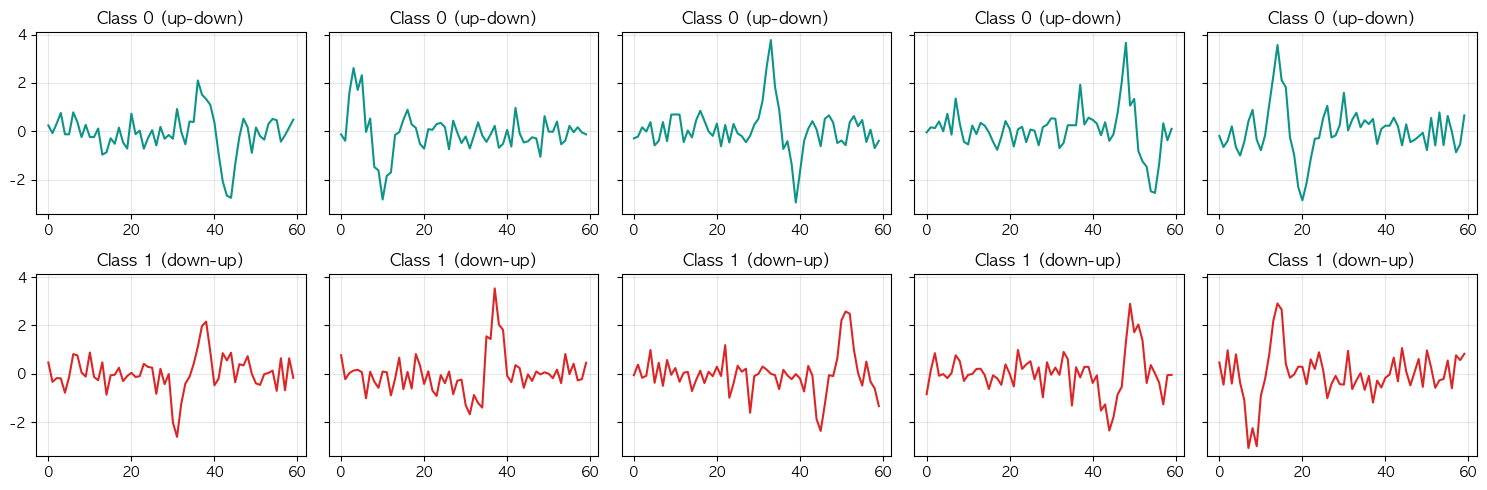

관찰 포인트:
  - 두 클래스 모두 노이즈 위에 11-스텝 펄스가 한 번 나타납니다.
  - Class 0 은 위로 솟구쳤다 내려오는 모양 (up-down)
  - Class 1 은 아래로 떨어졌다 올라오는 모양 (down-up)
  - 펄스 위치는 매 샘플마다 다릅니다 → DNN 의 위치 가중치 학습이 어려움


In [16]:
# [시나리오] 두 클래스의 샘플 시계열을 시각화합니다.
# 각 클래스에서 5개씩 골라 패턴이 무작위 위치에 있음을 확인합니다.

fig, axes = plt.subplots(2, 5, figsize=(15, 5), sharey=True)
idx0 = np.where(y == 0)[0][:5]
idx1 = np.where(y == 1)[0][:5]

for i in range(5):
    axes[0, i].plot(X[idx0[i]], color='#0D9488')
    axes[0, i].set_title("Class 0 (up-down)")
    axes[0, i].grid(alpha=0.3)
    axes[1, i].plot(X[idx1[i]], color='#DC2626')
    axes[1, i].set_title("Class 1 (down-up)")
    axes[1, i].grid(alpha=0.3)

plt.tight_layout(); plt.show()

print("관찰 포인트:")
print("  - 두 클래스 모두 노이즈 위에 11-스텝 펄스가 한 번 나타납니다.")
print("  - Class 0 은 위로 솟구쳤다 내려오는 모양 (up-down)")
print("  - Class 1 은 아래로 떨어졌다 올라오는 모양 (down-up)")
print("  - 펄스 위치는 매 샘플마다 다릅니다 → DNN 의 위치 가중치 학습이 어려움")


In [17]:
# [시나리오] 세 모델 정의 — DNN, 단방향 LSTM, Bi-LSTM

class DNNClassifier(nn.Module):
    """시계열을 펴서 그대로 받는 베이스라인 DNN."""
    def __init__(self, T):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(T, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 2), 
        )
    def forward(self, x):
        return self.net(x.squeeze(-1))   # (batch, T, 1) → (batch, T)


class LSTMClassifier(nn.Module):
    """단방향 LSTM many-to-one 분류기.

    Part 5 의 LSTMRegressor 와 같은 LSTM 구조이며,
    Linear 헤드 출력만 1 (회귀) → 2 (이진 분류) 로 바뀐 것 입니다.
    """
    def __init__(self, hidden=32):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=hidden, batch_first=True)
        self.head = nn.Linear(hidden, 2)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :])  # 마지막 시점 hidden


class BiLSTMClassifier(nn.Module):
    """Bi-LSTM many-to-one 분류기. h_T[0]/h_T[1] 을 명시적으로 결합."""
    def __init__(self, hidden=32):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=hidden,
                            batch_first=True, bidirectional=True)
        # bidirectional → hidden * 2 = 64
        self.head = nn.Linear(hidden * 2, 2)
    def forward(self, x):
        out, (h_T, _) = self.lstm(x)
        h_fw, h_bw = h_T[0], h_T[1]
        return self.head(torch.cat([h_fw, h_bw], dim=-1))


# 파라미터 수 비교
m_dnn = DNNClassifier(T=T_seq)
m_uni = LSTMClassifier(hidden=32)
m_bi  = BiLSTMClassifier(hidden=32)

for name, m in [("DNN     ", m_dnn), ("LSTM-uni", m_uni), ("LSTM-bi ", m_bi)]:
    n = sum(p.numel() for p in m.parameters())
    print(f"  {name}: {n:,} 파라미터")


  DNN     : 6,050 파라미터
  LSTM-uni: 4,546 파라미터
  LSTM-bi : 9,090 파라미터


In [18]:
# [시나리오] 세 모델을 같은 데이터로 학습 후 검증 정확도를 비교합니다.
# - 시드 고정 (재현성 확보)
# - 30 epoch, batch=32, AdamW(lr=1e-3, weight_decay=1e-4)
#
# ⚠️ 주의: 이 셀은 Part 5 의 X_tr/X_val/y_tr/y_val/train_loader/val_loader 등을
#         같은 이름의 분류용 변수로 덮어씁니다. Part 5 셀을 다시 단독 실행하려면
#         노트북을 위에서부터 다시 실행하세요.

from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.2,
                                            random_state=42, stratify=y)

X_tr_t  = torch.tensor(X_tr).unsqueeze(-1)
X_val_t = torch.tensor(X_val).unsqueeze(-1)
y_tr_t  = torch.tensor(y_tr)
y_val_t = torch.tensor(y_val)

train_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=32, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=32, shuffle=False)


def train_eval(model_ctor, label, epochs=30):
    torch.manual_seed(42)   # 동일 초기화 보장
    np.random.seed(42)
    model = model_ctor()
    opt = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    loss_fn = nn.CrossEntropyLoss()
    for ep in range(epochs):
        model.train()
        for Xb, yb in train_loader:
            opt.zero_grad()
            loss_fn(model(Xb), yb).backward()
            opt.step()
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for Xb, yb in val_loader:
            pred = model(Xb).argmax(dim=-1)
            correct += (pred == yb).sum().item()
            total += yb.size(0)
    acc = correct / total
    print(f"  [{label}] val accuracy = {acc:.4f}")
    return acc


print("학습 시작 (각 모델 30 epoch)...")
acc_dnn = train_eval(lambda: DNNClassifier(T=T_seq),     "DNN     ")
acc_uni = train_eval(lambda: LSTMClassifier(hidden=32),  "LSTM-uni")
acc_bi  = train_eval(lambda: BiLSTMClassifier(hidden=32), "LSTM-bi ")


학습 시작 (각 모델 30 epoch)...
  [DNN     ] val accuracy = 0.8750
  [LSTM-uni] val accuracy = 0.9850
  [LSTM-bi ] val accuracy = 1.0000


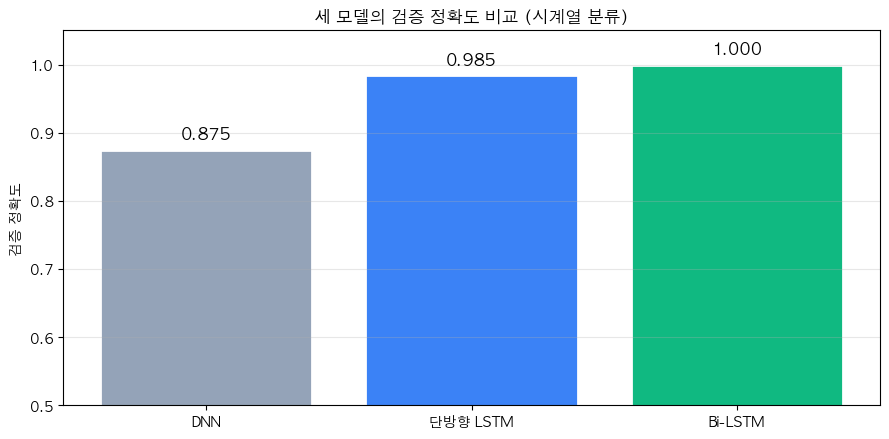


관찰 포인트:
  - DNN (0.875): 패턴 위치가 매번 달라 위치 가중치 학습이 어려움
  - 단방향 LSTM (0.985): 시퀀스를 훑으며 패턴 감지 — 큰 향상
  - Bi-LSTM (1.000): 양방향 정보 결합 — 가장 안정적

결론:
  1. 시계열 분류에서 시퀀스 모델 (LSTM) 이 DNN 보다 우수합니다.
  2. 양방향 정보가 필요한 과제에서는 Bi-LSTM 이 유리합니다.
  3. 단, Bi-LSTM 은 '전체 시퀀스가 알려진' 분류 과제에서만 사용 가능합니다.
     (예측·실시간 스트리밍 에서는 단방향 LSTM을 사용합니다.)


In [19]:
# [시나리오] 세 모델의 검증 정확도를 막대 그래프로 비교합니다.
# 이전 셀의 acc_dnn, acc_uni, acc_bi 를 사용합니다.

models = ["DNN", "단방향 LSTM", "Bi-LSTM"]
accs   = [acc_dnn, acc_uni, acc_bi]
colors = ['#94A3B8', '#3B82F6', '#10B981']

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.bar(models, accs, color=colors, edgecolor='white', linewidth=2)
ax.set_ylabel("검증 정확도"); ax.set_ylim(0.5, 1.05)
ax.set_title("세 모델의 검증 정확도 비교 (시계열 분류)")
for b, a in zip(bars, accs):
    ax.text(b.get_x() + b.get_width()/2, a + 0.015, f"{a:.3f}",
            ha='center', fontweight='bold', fontsize=12)
ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

print()
print("관찰 포인트:")
print(f"  - DNN ({acc_dnn:.3f}): 패턴 위치가 매번 달라 위치 가중치 학습이 어려움")
print(f"  - 단방향 LSTM ({acc_uni:.3f}): 시퀀스를 훑으며 패턴 감지 — 큰 향상")
print(f"  - Bi-LSTM ({acc_bi:.3f}): 양방향 정보 결합 — 가장 안정적")
print()
print("결론:")
print("  1. 시계열 분류에서 시퀀스 모델 (LSTM) 이 DNN 보다 우수합니다.")
print("  2. 양방향 정보가 필요한 과제에서는 Bi-LSTM 이 유리합니다.")
print("  3. 단, Bi-LSTM 은 '전체 시퀀스가 알려진' 분류 과제에서만 사용 가능합니다.")
print("     (예측·실시간 스트리밍 에서는 단방향 LSTM을 사용합니다.)")


---

## 핵심 정리

### 개념 한눈에 보기

| 주제 | 핵심 |
|------|------|
| 시계열의 본질 | 순서 자체가 정보. 섞으면 의미 파괴 |
| 슬라이딩 윈도우 | 긴 시계열을 (과거 W, 다음 1) 쌍으로 변환 |
| RNN | 은닉 상태 $h_t$ 로 시점 정보 누적, 가중치 공유 |
| RNN 한계 | BPTT 곱셈 구조 → 기울기 소실 → 장기 의존성 학습 어려움 |
| LSTM | 셀 상태 $C_t$ + 3개 게이트(forget·input·output) 로 정보 흐름 제어 |
| 정보 고속도로 | $C_t = f_t \odot C_{t-1} + \dots$ 의 덧셈 구조로 기울기 보존 |
| Bi-LSTM | 양방향 hidden concat, 분류·라벨링에 우수 (예측 X) |
| 시간 순 분할 | 미래 누수 방지, shuffle 금지 |

### 핵심 코드

| 코드 | 역할 |
|------|------|
| `nn.RNN(input_size, hidden_size, batch_first=True)` | 단순 RNN |
| `nn.LSTM(input_size, hidden_size, batch_first=True)` | LSTM |
| `nn.LSTM(..., bidirectional=True)` | Bi-LSTM |
| `out, (h_T, c_T) = lstm(x)` | LSTM 출력 (모든 hidden, 마지막 hidden, 마지막 cell) |
| `out[:, -1, :]` | many-to-one: 마지막 시점 hidden 추출 |
| `torch.cat([h_T[0], h_T[1]], dim=-1)` | Bi-LSTM many-to-one 분류 헤드용 결합 |

### 다음 시간 예고

본 챕터에서는 LSTM 으로 시퀀스를 한 벡터로 압축하는 **many-to-one** 만 다뤘습니다. 다음 챕터에서는 더 일반적이고 현대적인 시퀀스 처리 기법으로 확장합니다.

| 주제 | 한 줄 |
|------|-------|
| **인코더-디코더 (Seq2Seq)** | 인코더가 입력 시퀀스를 한 벡터로 압축 → 디코더가 출력 시퀀스 생성 (번역·요약) |
| **Attention** | "디코더가 매 시점마다 인코더의 어떤 시점을 봐야 할지" 학습 — 긴 시퀀스의 정보 병목 해결 |
| **Transformer** | RNN을 완전히 버리고 attention만으로 시퀀스 처리 — 병렬화로 학습 속도 대폭 향상, 현재 표준 |

> 다음 챕터에서 만나요!
